# ⚽ Análisis Exploratorio de Datos (EDA) - Premier League 2025-26
Este notebook contiene el análisis inicial de los datasets de partidos y eventos para la construcción de los modelos de xG y Match Predictor.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import Pitch
import json
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import unidecode

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
sns.set_palette('viridis')

## 1. Carga de Datos

In [2]:
df_matches = pd.read_csv('../data/matches.csv')
df_events = pd.read_csv('../data/events.csv')
df_players = pd.read_csv('../data/players.csv')

print(f"Matches: {df_matches.shape}")
print(f"Events: {df_events.shape}")
print(f"Players: {df_players.shape}")

Matches: (291, 41)
Events: (444252, 20)
Players: (822, 37)


## 2. EDA: Goles Esperados (xG)
Análisis de la ubicación de los tiros y su efectividad.

In [3]:
# Filtrar solo por tiros (is_shot == True)
df_shots = df_events[df_events['is_shot'] == True].copy()

print(f"Total de tiros en el dataset: {len(df_shots)}")
print(f"Total de goles: {df_shots['is_goal'].sum()}")
print(f"Conversión promedio: {df_shots['is_goal'].mean():.2%}")

Total de tiros en el dataset: 7198
Total de goles: 807
Conversión promedio: 11.21%


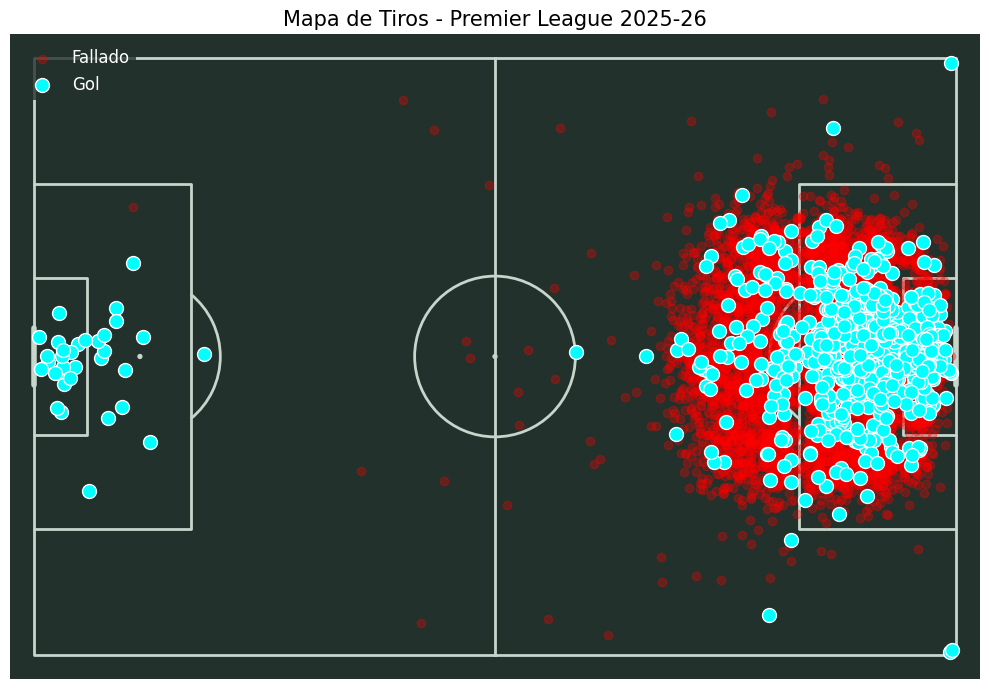

In [4]:
# Visualizar la ubicación de los tiros en la cancha
pitch = Pitch(pitch_type='opta', pitch_color='#22312b', line_color='#c7d5cc')
fig, ax = pitch.draw(figsize=(10, 7))

# Tiros que fueron gol (Azul) vs Fallados (Rojo)
pitch.scatter(df_shots[df_shots['is_goal'] == False]['x'], 
              df_shots[df_shots['is_goal'] == False]['y'], 
              ax=ax, color='red', alpha=0.3, label='Fallado')
pitch.scatter(df_shots[df_shots['is_goal'] == True]['x'], 
              df_shots[df_shots['is_goal'] == True]['y'], 
              ax=ax, color='cyan', edgecolors='white', s=100, label='Gol')

ax.legend(facecolor='#22312b', edgecolor='None', fontsize=12, labelcolor='white')
plt.title('Mapa de Tiros - Premier League 2025-26', color='black', fontsize=15)
plt.show()

## 3. EDA: Predicción de Partidos

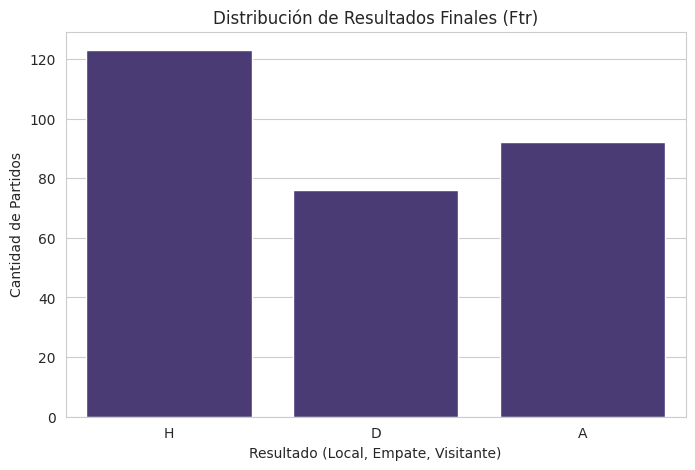

ftr
H    0.422680
A    0.316151
D    0.261168
Name: proportion, dtype: float64


In [5]:
# Distribución de resultados (Home, Draw, Away)
plt.figure(figsize=(8, 5))
sns.countplot(data=df_matches, x='ftr', order=['H', 'D', 'A'])
plt.title('Distribución de Resultados Finales (Ftr)')
plt.xlabel('Resultado (Local, Empate, Visitante)')
plt.ylabel('Cantidad de Partidos')
plt.show()

print(df_matches['ftr'].value_counts(normalize=True))

## 4. Feature Engineering: Contexto y Calificadores
Extracción de calificadores y cálculo de métricas geométricas/situacionales.

In [6]:
def parse_shot_qualifiers(qual_str):
    try:
        quals = json.loads(qual_str)
        q_ids = [q['type']['value'] for q in quals]
        return {
            'is_big_chance': 214 in q_ids,
            'is_header': 15 in q_ids,
            'is_counter': 23 in q_ids,
            'is_penalty': 9 in q_ids,
            'is_free_kick': 26 in q_ids
        }
    except:
        return {'is_big_chance': False, 'is_header': False, 'is_counter': False, 'is_penalty': False, 'is_free_kick': False}

quals_df = df_shots['qualifiers'].apply(parse_shot_qualifiers).apply(pd.Series)
df_shots = pd.concat([df_shots, quals_df], axis=1)

df_shots['distance'] = np.sqrt((100 - df_shots['x'])**2 + (50 - df_shots['y'])**2)
df_shots['angle'] = np.arctan2(abs(50 - df_shots['y']), (100 - df_shots['x']))

### 4.1 Análisis Situacional: Game State y Minutos Críticos

In [7]:
# Calcular el marcador en vivo para cada evento
df_events['is_goal_int'] = df_events['is_goal'].astype(int)
df_events['team_score'] = df_events.groupby(['match_id', 'team_name'])['is_goal_int'].cumsum() - df_events['is_goal_int']
df_events['match_total_goals'] = df_events.groupby('match_id')['is_goal_int'].cumsum() - df_events['is_goal_int']
df_events['opp_score'] = df_events['match_total_goals'] - df_events['team_score']
df_events['score_diff'] = df_events['team_score'] - df_events['opp_score']

df_shots = df_shots.merge(df_events[['id', 'score_diff']], on='id', how='left')
df_shots['is_late_half'] = df_shots['minute'].apply(lambda x: 1 if (x >= 40 and x <= 45) or (x >= 85) else 0)

### 4.2 Incorporando la Posición del Jugador (Fix Mapping)

In [8]:
import unidecode

def clean_name(name):
    if pd.isna(name):
        return ""
    return unidecode.unidecode(str(name).lower())

# Limpieza de nombres en ambas tablas
df_players['clean_web_name'] = df_players['web_name'].apply(clean_name)
df_shots['clean_player_name'] = df_shots['player_name'].apply(clean_name)

# Diccionario de mapeo rápido
name_to_pos = {row['clean_web_name']: row['position'] for _, row in df_players.iterrows()}

def fast_match_position(full_name):
    # Intento 1: Coincidencia exacta
    if full_name in name_to_pos:
        return name_to_pos[full_name]
    
    # Intento 2: ¿Está el web_name contenido en el nombre completo?
    for web_name, pos in name_to_pos.items():
        if len(web_name) > 3 and web_name in full_name:
            return pos
    return 'FWD' # Default minoritario si no se encuentra

df_shots['position'] = df_shots['clean_player_name'].apply(fast_match_position)

# One-Hot Encoding para posiciones
pos_dummies = pd.get_dummies(df_shots['position'], prefix='pos')
df_shots = pd.concat([df_shots, pos_dummies], axis=1)

print("Posiciones mapeadas y transformadas en variables dummy.")
print(df_shots['position'].value_counts())

Posiciones mapeadas y transformadas en variables dummy.
position
MID    3487
FWD    2181
DEF    1443
GKP      87
Name: count, dtype: int64


## 5. Modelo 1: Expected Goals (xG) Mejorado
Entrenamiento con variables de posición.

In [9]:
# Ver qué columnas de posición se crearon
pos_cols = [c for c in df_shots.columns if c.startswith('pos_')]

# Selección de características mejorada
features = ['distance', 'angle', 'is_big_chance', 'is_header', 'is_counter', 'is_penalty', 'is_late_half', 'score_diff'] + pos_cols
X = df_shots[features].fillna(0)
y = df_shots['is_goal'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model_xg = LogisticRegression(max_iter=2000)
model_xg.fit(X_train, y_train)

y_prob = model_xg.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

print(f"Modelo xG re-entrenado con posiciones. AUC: {auc:.3f}")

Modelo xG re-entrenado con posiciones. AUC: 0.774


### 5.2 Análisis de Coeficientes Finales

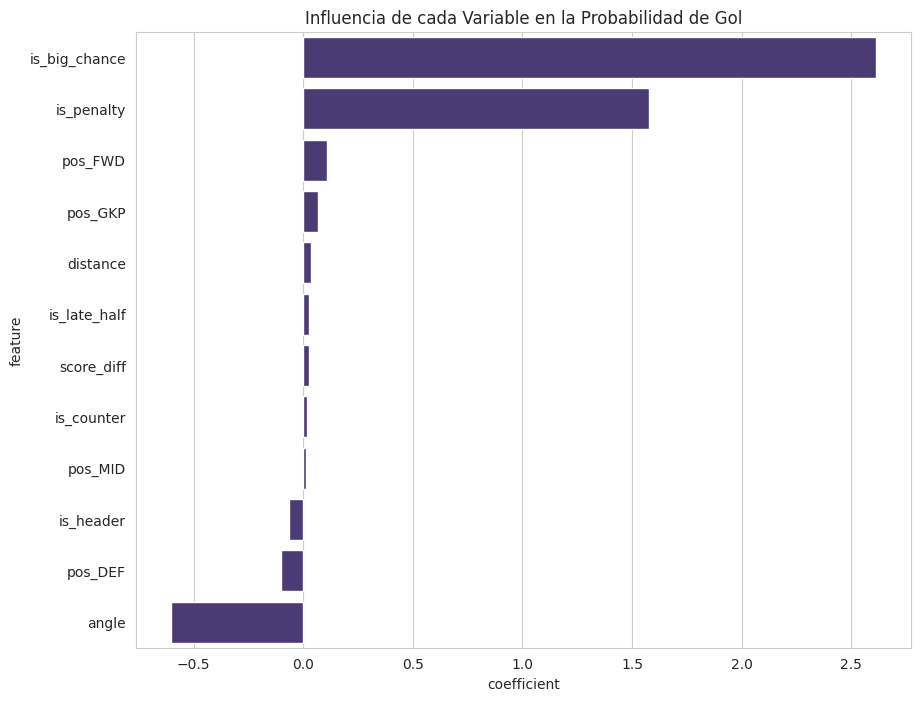

          feature  coefficient
2   is_big_chance     2.610854
5      is_penalty     1.575939
9         pos_FWD     0.107667
10        pos_GKP     0.066448
0        distance     0.033138
6    is_late_half     0.026928
7      score_diff     0.024473
4      is_counter     0.016565
11        pos_MID     0.010789
3       is_header    -0.063289
8         pos_DEF    -0.101911
1           angle    -0.603641


In [10]:
importance = pd.DataFrame({
    'feature': features,
    'coefficient': model_xg.coef_[0]
}).sort_values(by='coefficient', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance, x='coefficient', y='feature')
plt.title('Influencia de cada Variable en la Probabilidad de Gol')
plt.show()

print(importance)

## 5.3 — Curva ROC y AUC (modelo xG)

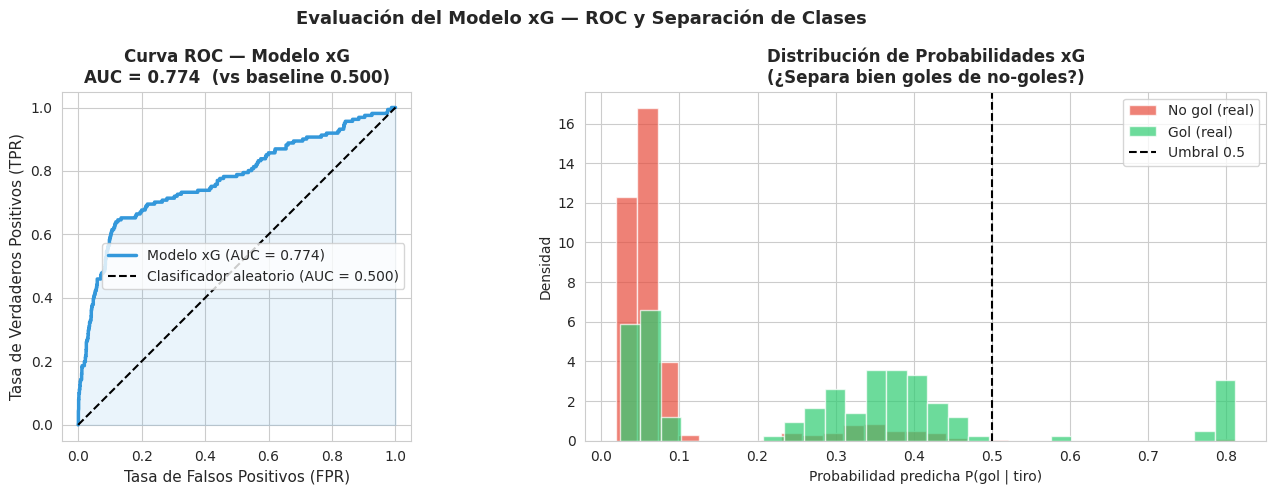

AUC = 0.774
Interpretación: el modelo asigna una probabilidad mayor a tiros reales que terminaron en gol
el 77.4% del tiempo — muy por encima del 50% del clasificador aleatorio.


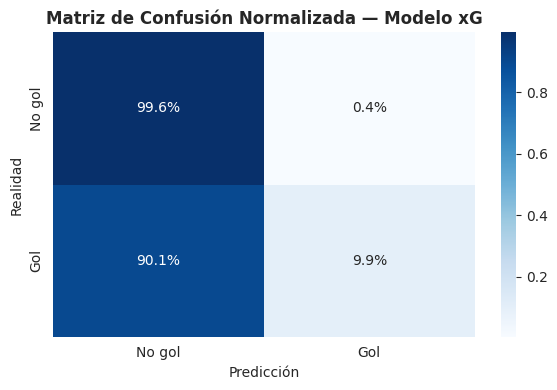


Reporte de Clasificación:
              precision    recall  f1-score   support

      No gol       0.90      1.00      0.94      1279
         Gol       0.76      0.10      0.18       161

    accuracy                           0.90      1440
   macro avg       0.83      0.55      0.56      1440
weighted avg       0.88      0.90      0.86      1440

Baseline naive (predecir siempre 'no gol'): 88.8% accuracy
Nuestro modelo:                              89.6% accuracy


In [11]:
from sklearn.metrics import roc_curve, auc as sk_auc

# El modelo ya está entrenado en la celda anterior — reutilizamos model_xg
y_prob_xg = model_xg.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_xg)
roc_auc = sk_auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Curva ROC ————————————————————————————————————————————————————————————————
axes[0].plot(fpr, tpr, color='#3498db', linewidth=2.5, label=f'Modelo xG (AUC = {roc_auc:.3f})')
axes[0].plot([0,1],[0,1], 'k--', linewidth=1.5, label='Clasificador aleatorio (AUC = 0.500)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#3498db')
axes[0].set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
axes[0].set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
axes[0].set_title(f'Curva ROC — Modelo xG\nAUC = {roc_auc:.3f}  (vs baseline 0.500)', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_aspect('equal')

# — Distribución de probabilidades predichas ——————————————————————————————————
axes[1].hist(y_prob_xg[y_test == 0], bins=30, alpha=0.7, color='#e74c3c',
             label='No gol (real)', density=True, edgecolor='white')
axes[1].hist(y_prob_xg[y_test == 1], bins=30, alpha=0.7, color='#2ecc71',
             label='Gol (real)',    density=True, edgecolor='white')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Umbral 0.5')
axes[1].set_xlabel('Probabilidad predicha P(gol | tiro)')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribución de Probabilidades xG\n'
                  '(¿Separa bien goles de no-goles?)', fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('Evaluación del Modelo xG — ROC y Separación de Clases',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"AUC = {roc_auc:.3f}")
print(f"Interpretación: el modelo asigna una probabilidad mayor a tiros reales que terminaron en gol")
print(f"el {roc_auc:.1%} del tiempo — muy por encima del 50% del clasificador aleatorio.")

# Matriz de confusión formal
from sklearn.metrics import confusion_matrix, classification_report
y_pred_xg = model_xg.predict(X_test)
cm_xg = confusion_matrix(y_test, y_pred_xg)
cm_norm = cm_xg.astype(float) / cm_xg.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues', ax=ax,
            xticklabels=['No gol','Gol'], yticklabels=['No gol','Gol'])
ax.set_title('Matriz de Confusión Normalizada — Modelo xG', fontweight='bold')
ax.set_xlabel('Predicción'); ax.set_ylabel('Realidad')
plt.tight_layout()
plt.show()

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_xg, target_names=['No gol','Gol']))
print(f"Baseline naive (predecir siempre 'no gol'): {(y_test==0).mean():.1%} accuracy")
print(f"Nuestro modelo:                              {(y_pred_xg==y_test).mean():.1%} accuracy")


## 6. EDA-3: Distribución Temporal de Goles y Análisis por Equipo

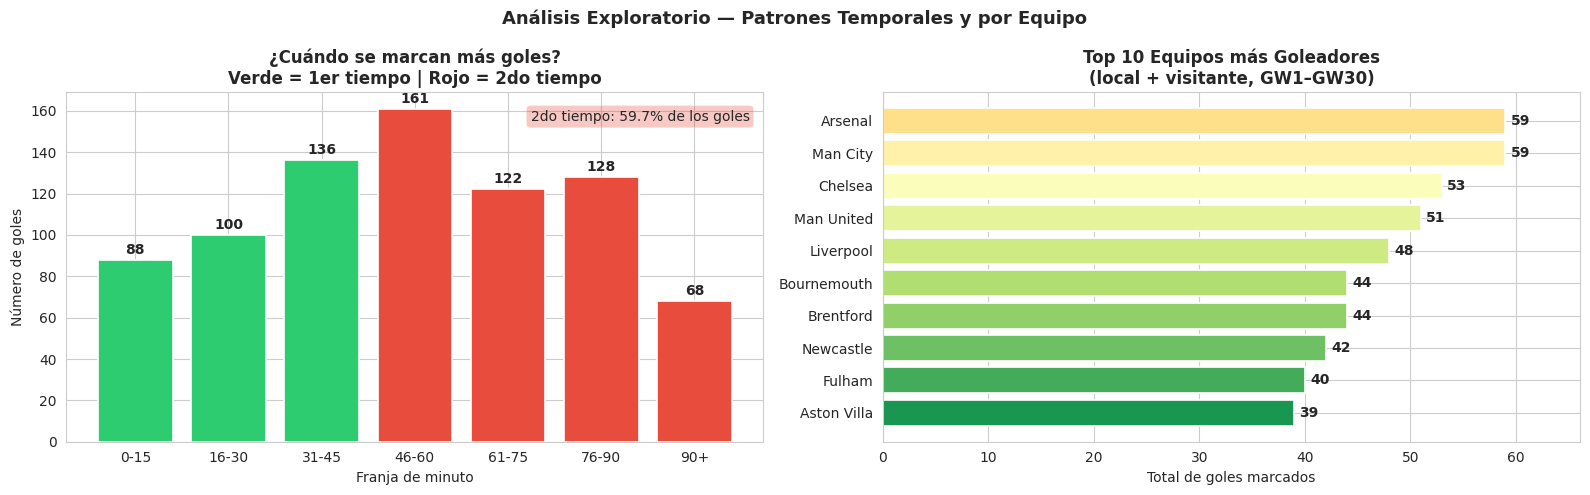

Insight 1: El 59.7% de los goles se marcan en el 2do tiempo — consistente con la literatura (fatiga defensiva).
Insight 2: Arsenal lidera con 59 goles marcados en 30 jornadas.


In [12]:
# EDA-3: dos visualizaciones adicionales — temporalidad y equipos

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# — 6.1: Goles por franja de minuto (¿cuándo se marcan más goles?) ——————————
bins = [0,15,30,45,60,75,90,105]
labels_b = ['0-15','16-30','31-45','46-60','61-75','76-90','90+']
goles = df_events[df_events['is_goal'] == True].copy()
goles['minuto_bin'] = pd.cut(goles['minute'], bins=bins, labels=labels_b, right=True)
goles_por_franja = goles['minuto_bin'].value_counts().reindex(labels_b)

colors_t = ['#2ecc71' if i < 3 else '#e74c3c' for i in range(len(labels_b))]
bars = axes[0].bar(labels_b, goles_por_franja.values, color=colors_t, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, goles_por_franja.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(val), ha='center', fontweight='bold', fontsize=10)
axes[0].set_xlabel('Franja de minuto')
axes[0].set_ylabel('Número de goles')
axes[0].set_title('¿Cuándo se marcan más goles?\n'
                  'Verde = 1er tiempo | Rojo = 2do tiempo', fontweight='bold')
axes[0].text(0.98, 0.95,
             f'2do tiempo: {goles_por_franja[labels_b[3:]].sum()/goles_por_franja.sum():.1%} de los goles',
             transform=axes[0].transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='#e74c3c', alpha=0.3), fontsize=10)

# — 6.2: Top 10 equipos goleadores (local + visitante) ———————————————————————
home_goals = df_matches.groupby('home_team')['fthg'].sum()
away_goals = df_matches.groupby('away_team')['ftag'].sum()
total_goals_team = (home_goals.add(away_goals, fill_value=0)
                              .sort_values(ascending=False)
                              .head(10))

colors_eq = plt.cm.RdYlGn(np.linspace(0.9, 0.4, 10))
bars2 = axes[1].barh(total_goals_team.index[::-1], total_goals_team.values[::-1],
                      color=colors_eq, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars2, total_goals_team.values[::-1]):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 str(int(val)), va='center', fontweight='bold', fontsize=10)
axes[1].set_xlabel('Total de goles marcados')
axes[1].set_title('Top 10 Equipos más Goleadores\n'
                  '(local + visitante, GW1–GW30)', fontweight='bold')
axes[1].set_xlim(0, total_goals_team.max() * 1.12)

plt.suptitle('Análisis Exploratorio — Patrones Temporales y por Equipo',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Insight 1: El {goles_por_franja[labels_b[3:]].sum()/goles_por_franja.sum():.1%} de los goles"
      f" se marcan en el 2do tiempo — consistente con la literatura (fatiga defensiva).")
print(f"Insight 2: {total_goals_team.idxmax()} lidera con {int(total_goals_team.max())} goles marcados en 30 jornadas.")
